<a href="https://colab.research.google.com/github/Smolry/Smart-HSRP-detection/blob/dev/Plate_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder("/content/drive/MyDrive/ML dataset/data.v0/train", transform=train_transforms)
val_dataset   = ImageFolder("/content/drive/MyDrive/ML dataset/data.v0/val", transform=val_test_transforms)
test_dataset  = ImageFolder("/content/drive/MyDrive/ML dataset/data.v0/test", transform=val_test_transforms)


In [6]:
print(train_dataset.class_to_idx)


{'hsrp': 0, 'non-hsrp': 1}


In [7]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


In [8]:
images, labels = next(iter(train_loader))
print(images.shape)   # [B, 3, 224, 224]
print(labels[:10])


torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 1, 0, 1, 1, 0, 1, 1])


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models


In [13]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Replace classifier head
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

model = model.to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


In [14]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


In [15]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


In [16]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.1
)


In [17]:
print("Trainable parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)



Trainable parameters:
classifier.1.weight
classifier.1.bias


In [18]:
criterion = nn.BCEWithLogitsLoss()


In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

    return running_loss / len(loader)


In [20]:
EPOCHS_PHASE1 = 5

best_val_loss = float("inf")

for epoch in range(EPOCHS_PHASE1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss = validate_one_epoch(
        model, val_loader, criterion
    )

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS_PHASE1}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "efficientnet_b0_phase1.pth")


Epoch [1/5] | Train Loss: 0.6813 | Val Loss: 0.6677
Epoch [2/5] | Train Loss: 0.6504 | Val Loss: 0.6366
Epoch [3/5] | Train Loss: 0.6253 | Val Loss: 0.6170
Epoch [4/5] | Train Loss: 0.6075 | Val Loss: 0.5990
Epoch [5/5] | Train Loss: 0.5880 | Val Loss: 0.5828


In [21]:
model.load_state_dict(
    torch.load("efficientnet_b0_phase1.pth", map_location=device)
)


<All keys matched successfully>

In [22]:
for param in model.features[-2:].parameters():
    param.requires_grad = True


In [23]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)


In [24]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=3,
    factor=0.1
)


In [25]:
EPOCHS_PHASE2 = 20

best_val_loss = float("inf")

for epoch in range(EPOCHS_PHASE2):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss = validate_one_epoch(
        model, val_loader, criterion
    )

    scheduler.step(val_loss)

    print(
        f"[FT] Epoch [{epoch+1}/{EPOCHS_PHASE2}] | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "efficientnet_b0_finetuned.pth")


[FT] Epoch [1/20] | Train: 0.5689 | Val: 0.5572
[FT] Epoch [2/20] | Train: 0.5477 | Val: 0.5386
[FT] Epoch [3/20] | Train: 0.5345 | Val: 0.5196
[FT] Epoch [4/20] | Train: 0.5074 | Val: 0.4973
[FT] Epoch [5/20] | Train: 0.4876 | Val: 0.4777
[FT] Epoch [6/20] | Train: 0.4756 | Val: 0.4647
[FT] Epoch [7/20] | Train: 0.4556 | Val: 0.4433
[FT] Epoch [8/20] | Train: 0.4377 | Val: 0.4340
[FT] Epoch [9/20] | Train: 0.4233 | Val: 0.4208
[FT] Epoch [10/20] | Train: 0.4147 | Val: 0.4107
[FT] Epoch [11/20] | Train: 0.4046 | Val: 0.3938
[FT] Epoch [12/20] | Train: 0.3865 | Val: 0.3912
[FT] Epoch [13/20] | Train: 0.3750 | Val: 0.3700
[FT] Epoch [14/20] | Train: 0.3723 | Val: 0.3696
[FT] Epoch [15/20] | Train: 0.3659 | Val: 0.3538
[FT] Epoch [16/20] | Train: 0.3562 | Val: 0.3470
[FT] Epoch [17/20] | Train: 0.3457 | Val: 0.3382
[FT] Epoch [18/20] | Train: 0.3438 | Val: 0.3284
[FT] Epoch [19/20] | Train: 0.3289 | Val: 0.3364
[FT] Epoch [20/20] | Train: 0.3311 | Val: 0.3226


In [26]:
model.load_state_dict(
    torch.load("efficientnet_b0_finetuned.pth", map_location=device)
)
model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [27]:
import torch
import numpy as np

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).int()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy().flatten())
        y_prob.extend(probs.cpu().numpy().flatten())


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1-score :", f1_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["HSRP", "NON_HSRP"]))


Accuracy : 0.8747152619589977
Precision: 0.8792270531400966
Recall   : 0.8584905660377359
F1-score : 0.8687350835322196

Classification Report:

              precision    recall  f1-score   support

        HSRP       0.87      0.89      0.88       227
    NON_HSRP       0.88      0.86      0.87       212

    accuracy                           0.87       439
   macro avg       0.87      0.87      0.87       439
weighted avg       0.87      0.87      0.87       439



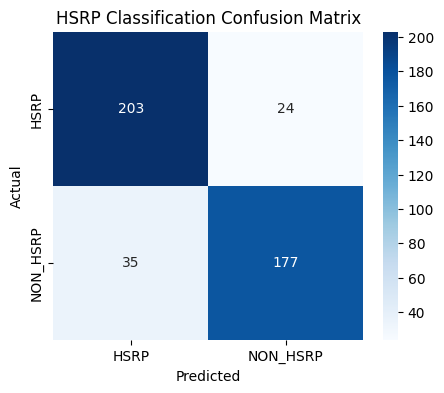

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["HSRP", "NON_HSRP"],
    yticklabels=["HSRP", "NON_HSRP"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("HSRP Classification Confusion Matrix")
plt.show()


In [29]:
import torch
import torch.nn as nn
from torchvision import models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.efficientnet_b0(pretrained=False)

# Replace classifier for binary classification
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)
model.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Prediction : HSRP
HSRP Prob  : 0.6157


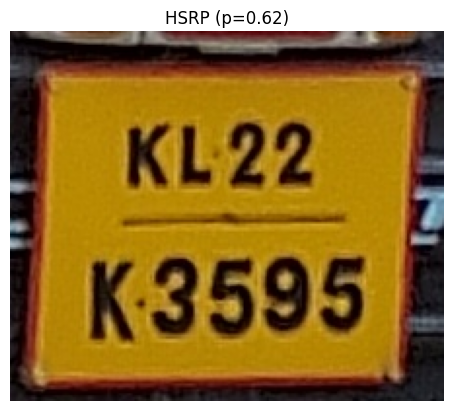

In [42]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Model
model = models.efficientnet_b0(pretrained=False)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model.load_state_dict(
    torch.load("efficientnet_b0_finetuned.pth", map_location=device)
)

model = model.to(device)
model.eval()

# Transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load image
img_path = "/content/drive/MyDrive/ML dataset/data.v0/test/non-hsrp/day_hsrp_001401.jpg"  # <-- CHANGE THIS
image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    logit = model(input_tensor)
    prob = torch.sigmoid(logit).item()

pred = "HSRP" if prob > 0.5 else "NON_HSRP"

print(f"Prediction : {pred}")
print(f"HSRP Prob  : {prob:.4f}")

# Display
plt.imshow(image)
plt.axis("off")
plt.title(f"{pred} (p={prob:.2f})")
plt.show()
